In [232]:
import numpy as np
import torch 
import torch.nn as nn 
import scipy.io 
import torch
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [233]:
data = scipy.io.loadmat('/Users/ramtarun/Desktop/Cambridge/Indirect-Noise-in-Nozzles/Data/Data_PINN_ff0.01He0N551_subsonic.mat')

In [234]:
eta = data['eta']
pi_p = data['pi_p']
pi_m = data['pi_m']
sig = data['sig']

N1 = eta.shape[1]

U = np.zeros((N1,4),dtype=float)
U[:,0] = eta
U[:,1] = pi_p
U[:,2] = pi_m
U[:,3] = sig

In [235]:
D = data['D']
M = data['M']
u = data['ubar']
dMdx = data['dMdx']
dudx = data['dudx']
alpha = data['alp']
eta1 = data['eta']    

#print(N1)

meanflow = np.zeros((N1,7),dtype=float)
meanflow[:,0] = D
meanflow[:,1] = M
meanflow[:,2] = u
meanflow[:,3] = dMdx
meanflow[:,4] = dudx
meanflow[:,5] = alpha
meanflow[:,6] = eta1

meanflow = torch.from_numpy(meanflow)
#print(meanflow)

In [236]:
he = torch.tensor([0.01])
HE = np.tile(he, (1,N1)) # N x T
He = HE.flatten()[:,None]
ETA = eta.flatten()[:, None]
Hee = torch.from_numpy(He).type(torch.float32)
ETA = torch.from_numpy(ETA).type(torch.float32)



UU = torch.from_numpy(U[:, 1:4]).type(torch.float32)

#ETA_train.requires_grad = True
He_train, He_test = train_test_split(Hee, train_size = 0.7, shuffle = True)
Eta_train, Eta_test, UU_train, UU_test = train_test_split(ETA, UU, train_size=0.7, shuffle=False)
#print(UU)


meanflow_train, meanflow_test = train_test_split(meanflow, train_size=0.7, shuffle=False)




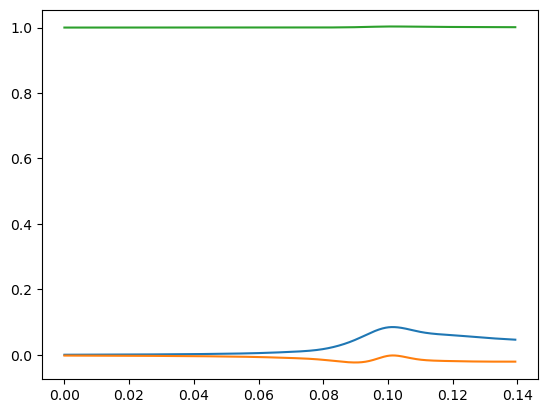

In [237]:
plt.plot(Eta_train, UU_train)


In [238]:
Eta_train.requires_grad = True
Eta_test.requires_grad = True
UU_train.requires_grad = True
UU_test.requires_grad = True

In [239]:
def RHS_f(x,y, baseflow, f):

    
    eta = x
    pi_p, pi_m, sig = torch.unbind(y,axis=1)

    D = baseflow[:,0]
    M = baseflow[:,1]
    u = baseflow[:,2]
    dMdx = baseflow[:,3]
    dudx = baseflow[:,4]
    alpha = baseflow[:,5]
    eta1 = baseflow[:,6]    
    
    He = 0#a constant input

    gamma = 1.4#constant
    
    Msq = torch.square(M)

    Lambda = 1 + Msq * (gamma-1)/2
    zeta = f*gamma*Msq - 2*torch.tan(alpha)
    C1= ((gamma - 1)*(1-Msq)*f)/(2*Lambda*zeta)
    Ca = -C1*M*u*dMdx*(2-(2*Msq/(1-Msq)) - (2*gamma*Msq*(-2*f*Lambda - (gamma-1)/gamma *zeta)/(2*Lambda*zeta)))
    Ff = -(dudx + (4*f*u/(2*D)))
    
    denom = (M**2*u - u + C1*Msq *u + C1*Msq*Msq*gamma*u) #M**4
    vrh_p = M*(2*(1-M) + C1*M*(M-2+M*gamma*(1-2*M)))/(2*denom)
    vrh_m = -M*(2*(1+M) + C1*M*(M+2+M*gamma*(1+2*M)))/(2*denom)
    vkp_p = Msq*C1*(2+M*(gamma-1))/(2*denom)
    vkp_m = Msq*C1*(2-M*(gamma-1))/(2*denom)
    vth_p = C1*M*(M*(1+gamma) + M**2*(1-gamma) - 2)/denom
    vth_m = C1*M*(M*(1+gamma) - M**2*(1-gamma) + 2)/denom
    vsig = -(C1*Msq*(1+gamma*Msq) + Msq - 1)/denom
    calM = dMdx/(2*M)
    kp_p = (gamma - 1) + (2/M)
    kp_m = (gamma - 1) - (2/M)
    Gm_p = M*(Ca*(M + 1) + Ff*M*(C1*gamma*M*Msq + M + (1 - C1*Msq)))/(2*denom)
    Gm_m = M*(Ca*(M - 1) - Ff*M*(C1*gamma*M*Msq + M - (1 - C1*Msq)))/(2*denom)
    Ups = (Ca*(Msq - 1) - C1*Ff*Msq*Msq *(1+gamma))/denom
    
#     eq1 = - (2*np.pi*1j*He*vrh_p + Gm_m*kp_m + calM)*pi_p + (2*np.pi*1j*He*vkp_p + Gm_m*kp_p + calM)*pi_m - Gm_m*sig
#     eq2 = - (2*np.pi*1j*He*vkp_m + Gm_p*kp_m - calM)*pi_p - (2*np.pi*1j*He*vrh_m + Gm_p*kp_p + calM)*pi_m - Gm_m*sig
#     eq3 = - (2*np.pi*1j*He*vth_p + Ups*kp_m)*pi_p - (2*np.pi*1j*He*vth_m + Ups*kp_p)*pi_m - (2*np.pi*1j*He*vsig + Ups)*sig
#     eq1 = - tf.multiply((Gm_m*kp_m + calM),pi_p) + tf.multiply(( Gm_m*kp_p + calM),pi_m) - tf.multiply(Gm_m,sig)

    eq1 = - (Gm_m*kp_m + calM)*pi_p + ( Gm_m*kp_p + calM)*pi_m - Gm_m*sig
    eq2 = - ( Gm_p*kp_m - calM)*pi_p - ( Gm_p*kp_p + calM)*pi_m - Gm_m*sig
    eq3 = - ( Ups*kp_m)*pi_p - ( Ups*kp_p)*pi_m - (Ups)*sig
    
    return torch.stack([-eq1, -eq2, -eq3],axis=1)

In [240]:
layers = np.array([2, 20, 20, 20, 20, 20, 20, 20, 20, 3]) # hidden layers
N_train = eta.shape[1]
N_train

551

In [241]:
# Neural Network for Predicting the pi+, pi-, and si.

class NN(nn.Module):
    def __init__(self, He, Eta, layers):
        super().__init__()

        'activation function'
        self.activation = nn.Tanh()
    
        'Initialize neural network as a list using nn.Modulelist'  
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
    
        'Xavier Normal Initialization'
        for i in range(len(layers)-1):
            
            nn.init.xavier_normal_(self.linears[i].weight.data, gain=1.0)
            
            # set biases to zero
            nn.init.zeros_(self.linears[i].bias.data)

        X = torch.cat([He, Eta],1)
    def forward(self, X):
        if torch.is_tensor(X) != True:         
            X = torch.from_numpy(X)   
        a = X.float()
        for i in range(len(layers) - 2):
            z = self.linears[i](a)
            a = self.activation(z)
        a = self.linears[-1](a)
        return a

In [255]:
# Physics informed Neural Network 
f = 0.25

class PINN(nn.Module):
    def __init__(self,He, Eta, uu, meanflow, layers):
        super().__init__()
        self.loss_function = nn.MSELoss(reduction ='mean')

        'Initialize our new parameters i.e.f (Inverse problem)' 
        self.f = torch.tensor([f], requires_grad=True).type(torch.float32)
        'Register f to optimize'
        self.f = nn.Parameter(self.f)
        'Initialize iterator'
        self.iter = 0
        'Call our DNN'
        self.dnn = NN(He, Eta, layers)
        'Register our new parameter'
        self.dnn.register_parameter('f', self.f)  
        
        self.meanflow = meanflow
        self.UU = uu

        X = torch.cat([He, Eta],1)

        self.X = X
        self.Eta = Eta
        
    def loss_data(self, X):
        g = torch.clone(X)
        R = self.dnn(g)
        loss_u = self.loss_function(R, self.UU)
        return loss_u
    
    def loss_residual(self, Eta, X):
        f = self.f
        g = torch.clone(X)
        R = self.dnn(g)
        GR = RHS_f(Eta, R, self.meanflow, f)
        dr_dn = torch.autograd.grad(R,Eta,torch.ones_like(R), retain_graph=True, create_graph=True)[0]
        pde = dr_dn + GR
        null = torch.zeros(Eta.shape[0],1)#to minimize function
        loss_r = self.loss_function(pde.float(), null.float())
        return loss_r
    
    def Loss(self, X, Eta):
        loss_data = self.loss_data(X)
        loss_residual = self.loss_residual(Eta, X)
        return loss_data + loss_residual
    

    'callable for optimizer'                                       
    def closure(self):
        
        optimizer.zero_grad()
        
        loss = self.Loss(self.X, self.Eta)
        
        loss.backward()
                
        self.iter += 1
        
        if self.iter % 200 == 0:
            print('f_real = [0.01], f_PINN = [%.3f]' %(self.f.item()))
            
        return loss


In [258]:
#torch.cuda.manual_seed(22)
epochs=2000
learning_rate=1e-4
N_train = torch.cat([He_train, Eta_train],1)
N_test = torch.cat([He_test, Eta_test], 1)
PINN_model = PINN(He_train, Eta_train, UU_train, meanflow_train, layers)
params = list(PINN_model.parameters())
#optimizer = torch.optim.LBFGS(params, learning_rate, 
                              #max_iter = epochs, 
                              #max_eval = None, 
                              #tolerance_grad = 1e-11, 
                              #tolerance_change = 1e-11, 
                              #history_size = 100, 
                              #line_search_fn = 'strong_wolfe')
optimizer = torch.optim.Adam(params, lr = learning_rate, amsgrad = False)

Training Loss
f_real = [0.01], f_PINN = [0.246]
f_real = [0.01], f_PINN = [0.214]
f_real = [0.01], f_PINN = [0.181]
f_real = [0.01], f_PINN = [0.151]
f_real = [0.01], f_PINN = [0.123]
f_real = [0.01], f_PINN = [0.099]
f_real = [0.01], f_PINN = [0.077]
f_real = [0.01], f_PINN = [0.057]
f_real = [0.01], f_PINN = [0.041]
f_real = [0.01], f_PINN = [0.027]


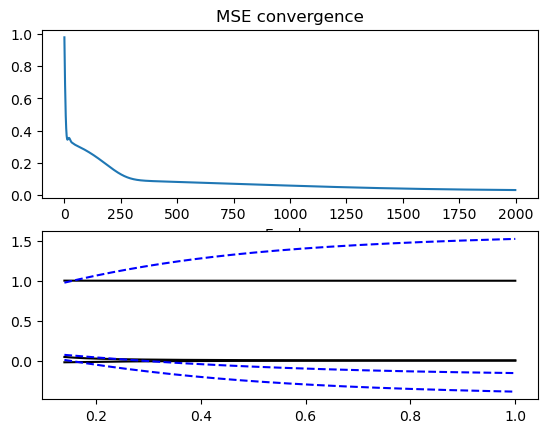

In [259]:
PINN_model.train()
epoch_loss = {}
for i in range(epochs):
    
    if i==0:
      print("Training Loss")
    loss = PINN_model.Loss(N_train, Eta_train)# use mean squared error
    optimizer.zero_grad()
    loss.backward()
    epoch_loss[i] = loss.item()
    optimizer.step(PINN_model.closure)

  
R_pred = PINN_model.dnn(N_test)

"""
PINN_model.eval()
          
with torch.inference_mode():
   ##Forward Pass 
   R_pred = PINN_model.dnn(N_test)
   accuracy(meanflow_test, R_pred, pct = 0.03)
"""

plt.subplot(2,1,1)
plt.plot(epoch_loss.keys(), epoch_loss.values())
plt.title('MSE convergence')
plt.xlabel('Epochs')
plt.subplot(2,1,2)
plt.plot(Eta_test.detach(), UU_test.detach(), 'black')
plt.plot(Eta_test.detach(),R_pred.detach(), 'b--')